# Notebook chính của dự án
Chạy toàn bộ pipeline phát hiện xâm nhập mạng thời gian thực.

<class 'pandas.DataFrame'>
RangeIndex: 2522362 entries, 0 to 2522361
Data columns (total 71 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  Flow IAT Mi

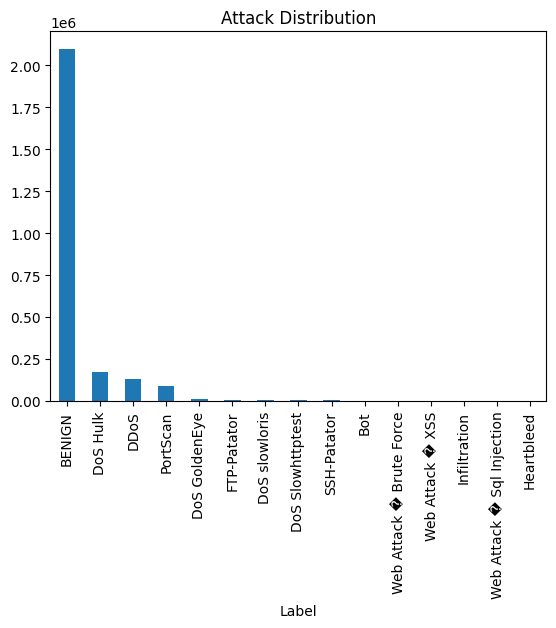

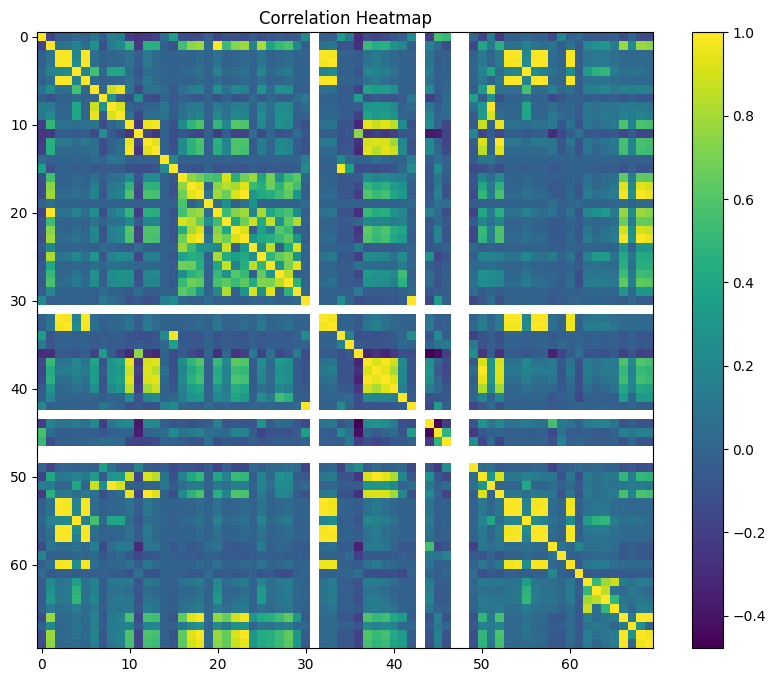

In [2]:
## 2.2 Exploratory Data Analysis & Data Preprocessing
# ==========================================
# Thai Trung Quoc Hieu (TASK 2.2)
# EDA & Tiền xử lý: Gộp CSV, làm sạch, tối ưu bộ nhớ, vẽ biểu đồ, xuất dữ liệu sạch.
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
df = pd.read_csv("../data/processed/cleaned_data.csv")
df.head()

df.shape
df.info()
df.describe()

df['Label'].value_counts().plot(kind='bar')
plt.title("Attack Distribution")
plt.show()

sample_df = df.sample(5000, random_state=42)
corr = sample_df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
plt.imshow(corr)
plt.title("Correlation Heatmap")
plt.colorbar()
plt.show()

# ### Nhận xét:

# - Dataset bị mất cân bằng nghiêm trọng (BENIGN chiếm đa số)
# - Một số feature có tương quan cao → cần feature selection
# - Cần xử lý imbalance ở bước tiếp theo (SMOTE)

In [3]:
# ==========================================
# Nguyen Gia Huy (TASK 2.3 & 2.4)
# 2.3 Mất cân bằng & 2.4 Chọn đặc trưng: Mã hóa, chuẩn hóa, cân bằng, chọn 18 đặc trưng, chia dữ liệu.
# ==========================================
##load data
df = pd.read_csv('../data/processed/cleaned_data.csv')
df.head()

##ENCODE LABEL
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])

#print(df['Label'].head()) dòng này để test chức năng mã hóa xem có thật sự chạy được
#nếu thấy số là oke

##18 features
features = [
'Destination Port',
'Flow Duration',
'Total Fwd Packets',
'Total Backward Packets',
'Total Length of Fwd Packets',
'Total Length of Bwd Packets',
'Fwd Packet Length Mean',
'Bwd Packet Length Mean',
'Flow Bytes/s',
'Flow Packets/s',
'Packet Length Mean',
'Packet Length Std',
'SYN Flag Count',
'ACK Flag Count',
'FIN Flag Count',
'RST Flag Count',
'PSH Flag Count',
'URG Flag Count'
]


X = df[features]
y = df['Label']

print(X.shape)

##chuẩn hóa
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# print(X_scaled[:5]) dòng này để test chức năng xem có thật sự chạy được
# đúng sẽ ra [[-0.12  0.45  1.23 ...]

##chia train/tets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
#test: 
#print(X_train.shape)
#print(X_test.shape)
#Kết quả đúng: train lớn hơn test

##xử lý mất cân bằng (smote)
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(
    sampling_strategy={
        0: 200000  
    },
    random_state=42
)

X_res, y_res = rus.fit_resample(X_train, y_train)

##KIỂM TRA Smote 
print("Before:", y_train.value_counts())
print("After:", pd.Series(y_res).value_counts())


##tạo folder nếu chưa có
#os.makedirs('data', exist_ok=True)

##lưu data
np.save('../data/processed/X_train.npy', X_res)
np.save('../data/processed/y_train.npy', y_res)
np.save('../data/processed/X_test.npy', X_test)
np.save('../data/processed/y_test.npy', y_test)
#sau khi chạy tạo ra 4 file .npy sẽ lưu vào folder "data/processed" trong thư mục nếu có rồi thì không có gì xảy ra

 

(2522362, 18)
Before: Label
0     1677336
4      137996
2      102518
10      72632
3        8254
7        4773
6        4300
5        4190
11       2586
1        1550
12       1176
14        517
9          32
13         20
8           9
Name: count, dtype: int64
After: Label
0     200000
4     137996
2     102518
10     72632
3       8254
7       4773
6       4300
5       4190
11      2586
1       1550
12      1176
14       517
9         32
13        20
8          9
Name: count, dtype: int64


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Hàm vẽ biểu đồ chuyên nghiệp giống nhóm
def plot_results(y_true, y_pred, model_name):
    print(f"\n=== KẾT QUẢ {model_name.upper()} ===")
    print(classification_report(y_true, y_pred))
    
    # Vẽ Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens') # Dùng màu xanh lá cho khác biệt
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Thực tế')
    plt.xlabel('Dự đoán')
    plt.show()


🔥 Đang 'vắt kiệt' CPU để luyện: Logistic Regression (SGD)...

=== KẾT QUẢ LOGISTIC REGRESSION (SGD) ===


/home/huymindhack/.local/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/huymindhack/.local/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/huymindhack/.local/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

              precision    recall  f1-score   support

           0       0.91      1.00      0.95    419148
           1       0.00      0.00      0.00       403
           2       0.95      0.53      0.68     25498
           3       0.96      0.21      0.34      2032
           4       0.89      0.82      0.86     34853
           5       0.00      0.00      0.00      1038
           6       0.00      0.00      0.00      1085
           7       0.00      0.00      0.00      1160
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         4
          10       0.00      0.00      0.00     18187
          11       0.00      0.00      0.00       633
          12       0.00      0.00      0.00       294
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00       135

    accuracy                           0.91    504473
   macro avg       0.25      0.17      0.19    504473
weighted avg       0.87   

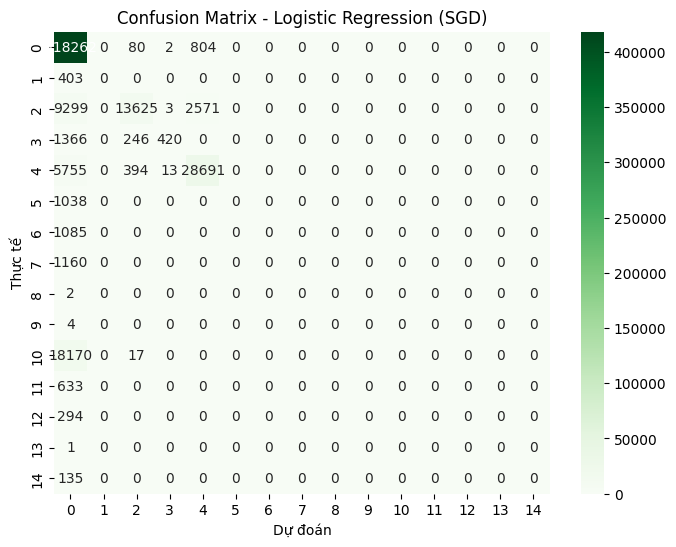

💾 Đã lưu model tại: ../models/logistic_regression_sgd.pkl

🔥 Đang 'vắt kiệt' CPU để luyện: SVM (SGD)...

=== KẾT QUẢ SVM (SGD) ===


/home/huymindhack/.local/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/huymindhack/.local/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/huymindhack/.local/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

              precision    recall  f1-score   support

           0       0.91      1.00      0.96    419148
           1       0.00      0.00      0.00       403
           2       0.99      0.52      0.68     25498
           3       0.49      0.34      0.40      2032
           4       0.91      0.82      0.86     34853
           5       0.00      0.00      0.00      1038
           6       0.00      0.00      0.00      1085
           7       0.00      0.00      0.00      1160
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         4
          10       0.00      0.00      0.00     18187
          11       0.00      0.00      0.00       633
          12       0.00      0.00      0.00       294
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00       135

    accuracy                           0.92    504473
   macro avg       0.22      0.18      0.19    504473
weighted avg       0.87   

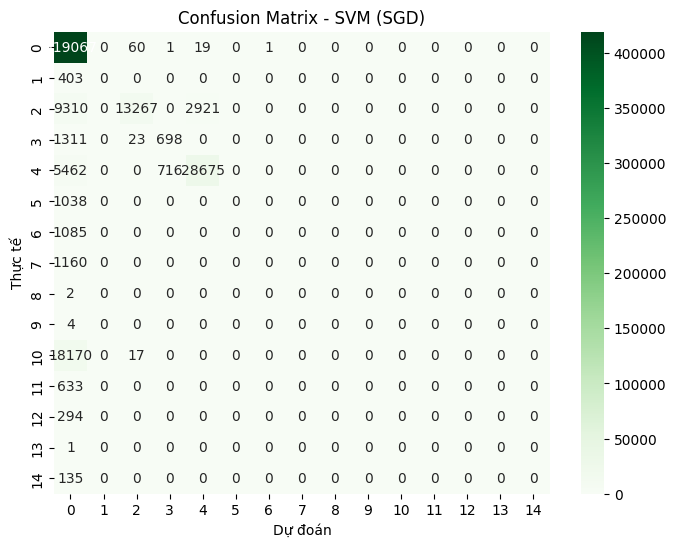

💾 Đã lưu model tại: ../models/svm_sgd.pkl

🔥 Đang 'vắt kiệt' CPU để luyện: Naive Bayes...

=== KẾT QUẢ NAIVE BAYES ===
              precision    recall  f1-score   support

           0       1.00      0.28      0.43    419148
           1       0.00      1.00      0.00       403
           2       0.69      0.45      0.55     25498
           3       0.04      0.99      0.07      2032
           4       0.91      0.42      0.57     34853
           5       0.06      0.14      0.09      1038
           6       0.21      0.57      0.30      1085
           7       0.68      1.00      0.81      1160
           8       1.00      0.50      0.67         2
           9       0.00      0.75      0.00         4
          10       0.53      0.99      0.69     18187
          11       0.37      0.93      0.52       633
          12       0.01      0.00      0.00       294
          13       0.00      1.00      0.00         1
          14       0.00      0.00      0.00       135

    accuracy   

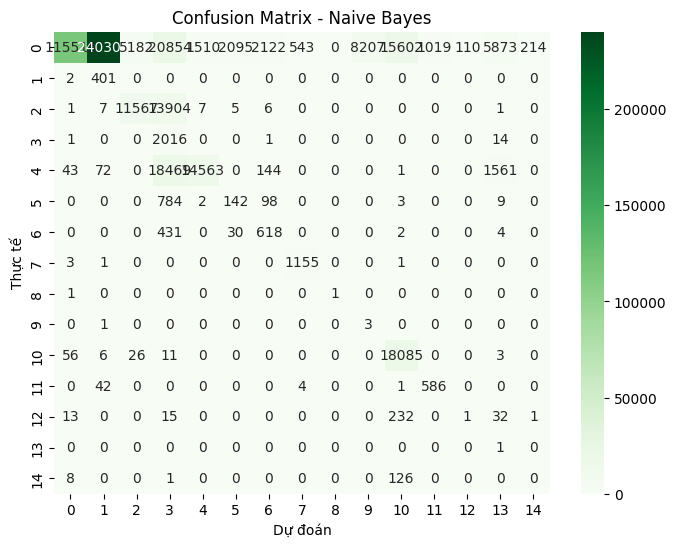

💾 Đã lưu model tại: ../models/naive_bayes.pkl


In [8]:
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import GaussianNB
import joblib

# 1. Định nghĩa danh sách mô hình sử dụng SGD để tối ưu CPU
# n_jobs=-1 giúp huy dùng hết sức mạnh chip Mac
models = {
    'Logistic Regression (SGD)': SGDClassifier(
        loss='log_loss', 
        n_jobs=-1, 
        learning_rate='optimal',
        max_iter=1000,
        random_state=42
    ),
    'SVM (SGD)': SGDClassifier(
        loss='hinge', # hinge loss chính là Linear SVM
        n_jobs=-1, 
        learning_rate='optimal',
        max_iter=1000,
        random_state=42
    ),
    'Naive Bayes': GaussianNB()
}

# 2. Vòng lặp chạy song song (nếu dùng SGD thì chạy tuần tự cũng đã rất nhanh rồi)
for name, model in models.items():
    print(f"\n🔥 Đang 'vắt kiệt' CPU để luyện: {name}...")
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    # Hiển thị kết quả và biểu đồ ngay trong Notebook
    plot_results(y_test, y_pred, name)
    
    # Lưu model vào đúng thư mục cho Khải làm Demo
    file_name = name.replace(' ', '_').lower().replace('(', '').replace(')', '')
    joblib.dump(model, f'../models/{file_name}.pkl')
    print(f"💾 Đã lưu model tại: ../models/{file_name}.pkl")